# Cross-Modal Diagnostic Observability — Stage T2-D

## AMW-DDET：主动最小 target witness 的定向迁移证书

本 notebook 把 Stage T1-R 的 oracle 机制发现转化为一个可部署的少标签问题：给定目标域上所有候选源模型的连续分数，只选择少量独立目标组获取标签，估计每条源→目标边的目标 AUC，并允许输出 `UNIDENTIFIABLE`。

主方法 **AMW-DDET** 使用 25% 随机 anchor、75% 组级 D-optimal 选择、group-aware cross-fitted ridge logistic 后验，以及全目标无标签分布上的加权 Mann–Whitney 插件 AUC。它与随机直接估计、随机 logistic 插件、随机半监督共享协方差高斯混合、主动直接估计比较。

**治理边界：**这仍是使用 30 条已解封边的 development-only 方法开发，不是独立验证；运行成功最多只授权冻结方法和撰写 blind 预注册。不会解析三个 locked-blind 标记，不会开启 Stage 12。

普通 CPU，正式 100 次重复预计 15–30 分钟。请在干净运行时执行一次 `Run all`。


In [1]:
# @title T2-D-0. Mount Drive, resolve immutable parents, verify hashes, and seal protocol
import hashlib, itertools, json, os, platform, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import solve_triangular
from scipy.special import logit, logsumexp
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore', category=RuntimeWarning)
try:
    from IPython.display import display
except Exception:
    display = print

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    pass

LOCAL_MODE = bool(os.environ.get('DDET_LOCAL_MODE'))
DEFAULT_ROOT = Path('/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability') if IN_COLAB else Path.cwd()
PROJECT_ROOT = Path(os.environ.get('CDO_PROJECT_ROOT', str(DEFAULT_ROOT)))
CODE_ROOT = PROJECT_ROOT/'05_Code'/'Cross_Modal' if not LOCAL_MODE else Path.cwd()
CM_ROOT = PROJECT_ROOT/'06_Data_Records'/'Cross_Modal' if not LOCAL_MODE else Path(os.environ.get('DDET_LOCAL_RECORD','/tmp/AMW_DDET_Local_Record'))
RESULT_ROOT = CM_ROOT/'StageT2-D_Development_Only_AMW-DDET_Active_Minimal_Witness_Certificate_v0.1'
P0,P1,P2,P3,P4 = [RESULT_ROOT/x for x in ['00_Protocol','01_Replicate_Results','02_Comparisons','03_Certificates_And_Gates','04_Results']]
for path in [CODE_ROOT,P0,P1,P2,P3,P4]: path.mkdir(parents=True, exist_ok=True)

NOTEBOOK_NAME = 'CrossModal_StageT2-D_Development_Only_AMW-DDET_Active_Minimal_Witness_Certificate_v0.1.ipynb'
NOTEBOOK_PATH = CODE_ROOT/NOTEBOOK_NAME
THEORY_NAME = 'Directed_Diagnostic_Evidence_Transport_Theory_and_Method_v0.3.md'
PREREG_NAME = 'StageT2-D_AMW-DDET_Development_Only_Preregistration_v0.1.md'
LOCKED_MARKERS = ['BUSI_CAIRO_2019','OASBUD_2017','DERM7PT_2019']
EXPECTED = {
    'edge_library':'f074467614321e4162a3aa4ad982b62edfa362d6238edeb2f69be6d4d50f09a9',
    'stage7_predictions':'4292324ae0053bdd91fb959641ad5b545b8db22967eb30fa64e83690d3871f17',
    'stage8_predictions':'e8f019d1beaf6716e780825894651318974c0780982b55d5f0481216f0c6602f',
    'stage8b_predictions':'33a8b2312df5c0e9576de1c5211e82a158177a89e321ba667252fb485a393329',
    'stage11f_predictions':'6ace342fbd6928f1041e80c446e79a501d8c23f618ebc4a3c671fc98d899a80d',
    'theory':'3dc9ce138bf85a14ee314e71314fbc8223fd6f54cd563f18dfe357a9fee0f73d',
    'preregistration':'f9e4a54d6c468952bd4c7404298ce9f240bfabe8da41548e979418f558d3fc5b',
}
SEED = 20260722
BUDGETS = [8,16,32,64,128]
N_REPLICATES = int(os.environ.get('DDET_FAST_REPS','20')) if LOCAL_MODE else 100
N_NEGATIVE = int(os.environ.get('DDET_FAST_NEG','10')) if LOCAL_MODE else 50
MIN_GROUPS = 40
RIDGE_C = 3.0
ALPHA = 0.10
THRESHOLDS = {
    'targets_min':13,'modalities_min':4,'edges_min':27,
    'mae_max':0.04,'relative_improvement_min':0.25,'signflip_p_max':0.05,
    'edge_spearman_min':0.80,'modalities_noninferior_min':3,
    'coverage_min':0.85,'wrong_decision_rate_max':0.05,
    'decision_coverage_min':0.10,'negative_control_median_deviation_max':0.05,
}

def now(): return datetime.now(timezone.utc).isoformat()
def sha_file(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda:handle.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
def sha_json(value): return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',',':'),ensure_ascii=False).encode()).hexdigest()
def canonical_csv(frame): return frame.fillna('').to_csv(index=False,lineterminator='\n',float_format='%.12g')
def write_text_once(path,text):
    path=Path(path)
    if path.exists(): assert path.read_text(encoding='utf-8')==text,f'Replay conflict: {path}'
    else: path.write_text(text,encoding='utf-8')
def write_csv_once(path,frame): write_text_once(path,canonical_csv(frame))
def write_json_once(path,value): write_text_once(path,json.dumps(value,indent=2,ensure_ascii=False)+'\n')
def verify_self(path,field):
    value=json.loads(Path(path).read_text(encoding='utf-8')); claim=value[field]
    core=dict(value); core.pop(field)
    assert sha_json(core)==claim,f'Self-hash mismatch: {path}'
    return value
def seal(path,payload,hash_field,time_field):
    path=Path(path)
    if path.exists():
        old=verify_self(path,hash_field)
        for key,value in payload.items(): assert old[key]==value,f'Sealed field changed: {key}'
        return old
    value=dict(payload); value[time_field]=now(); value[hash_field]=sha_json(value); write_json_once(path,value); return value
def notebook_source_sha256(path):
    value=json.loads(Path(path).read_text(encoding='utf-8')); cells=[]
    for cell in value.get('cells',[]):
        if cell.get('cell_type') not in {'code','markdown'}: continue
        source=cell.get('source',[]); source=''.join(source) if isinstance(source,list) else str(source)
        cells.append({'cell_type':cell['cell_type'],'source':source.replace('\r\n','\n')})
    return sha_json(cells)

if LOCAL_MODE:
    PATHS = {
        'edge_library':Path.cwd()/'edges.csv','stage7_predictions':Path.cwd()/'s7.csv',
        'stage8_predictions':Path.cwd()/'s8.csv','stage8b_predictions':Path.cwd()/'s8b.csv',
        'stage11f_predictions':Path.cwd()/'s11.csv','theory':Path.cwd()/THEORY_NAME,
        'preregistration':Path.cwd()/PREREG_NAME,
    }
    t1={'decision':'AUTHORISE_DDET_MINIMAL_WITNESS_METHOD_DEVELOPMENT','stage12_authorised':False,'locked_blind_assets_touched':False}
else:
    RETINAL = PROJECT_ROOT/'06_Data_Records'/'Retinal_DR'/'Prospective_Retinal_Blind_Test_v0.1'
    STAGE7 = RETINAL/'Stage7_PostUnseal_FourDomain_Transportability_Discovery_And_DDO2_Prototype_v0.1'
    STAGE8 = CM_ROOT/'Stage8_CrossModality_EdgeLibrary_Expansion_v0.1'
    STAGE8B = CM_ROOT/'Stage8B_NLM_Chest_Radiography_Access_Completion_v0.1'
    STAGE11F = CM_ROOT/'Stage11F-R_Development_Only_Directed_Edge_Assembly_And_Fit_Readiness_v0.2'
    PATHS = {
        'edge_library':STAGE11F/'03_Expanded_Edge_Library'/'Stage11F-R_FourModality_Eligible_Edge_Library_v0.2.csv',
        'stage7_predictions':STAGE7/'01_Four_Domain_Edge_Matrix'/'Stage7_FourDomain_Unit_Predictions_v0.1.csv',
        'stage8_predictions':STAGE8/'05_Unsealed_Discovery'/'Stage8_Evaluated_Unit_Predictions_v0.1.csv',
        'stage8b_predictions':STAGE8B/'05_Unsealed_Chest_Discovery'/'Stage8B_Evaluated_Chest_Unit_Predictions_v0.1.csv',
        'stage11f_predictions':STAGE11F/'02_Development_Transfer_Outcomes'/'Stage11F-R_Evaluated_Ultrasound_Target_Predictions_v0.2.csv',
        'theory':PROJECT_ROOT/'03_Theory'/'Directed_Diagnostic_Evidence_Transport_v0.3'/THEORY_NAME,
        'preregistration':PROJECT_ROOT/'04_Study_Design'/PREREG_NAME,
    }
    T1_FINAL=CM_ROOT/'StageT1-R_Development_Only_DDET_Mechanism_Kill_Test_v0.1'/'04_Results'/'StageT1-R_Complete_v0.1.json'
    assert T1_FINAL.is_file(),f'Missing T1-R final record: {T1_FINAL}'
    t1=verify_self(T1_FINAL,'final_record_sha256')

assert NOTEBOOK_PATH.is_file(),f'Notebook must be stored at {NOTEBOOK_PATH} before Run all'
missing=[str(path) for path in PATHS.values() if not path.is_file()]
assert not missing,'Missing immutable inputs:\n'+'\n'.join(missing)
for role,path in PATHS.items(): assert sha_file(path)==EXPECTED[role],f'Hash mismatch: {role}'
resolved='|'.join(map(str,PATHS.values()))
assert not any(marker.lower() in resolved.lower() for marker in LOCKED_MARKERS),'Locked marker resolved'
assert str(t1['decision']).startswith('AUTHORISE_DDET_MINIMAL_WITNESS_METHOD_DEVELOPMENT')
assert t1['stage12_authorised'] is False and t1['locked_blind_assets_touched'] is False

protocol_payload={
    'stage':'StageT2-D','analysis':'development_only_active_minimal_witness_certificate',
    'input_sha256':EXPECTED,'notebook_source_sha256':notebook_source_sha256(NOTEBOOK_PATH),
    'seed':SEED,'budgets':BUDGETS,'formal_replicates':100,'formal_negative_control_replicates':50,
    'minimum_independent_groups':MIN_GROUPS,'ridge_C':RIDGE_C,'random_anchor_fraction':0.25,
    'conformal_alpha':ALPHA,'thresholds':THRESHOLDS,'stage12_authorised':False,
    'locked_blind_assets_touched':False,
}
protocol=seal(P0/'StageT2-D_AMW-DDET_Protocol_Seal_v0.1.json',protocol_payload,'seal_sha256','sealed_utc')
commitment=pd.DataFrame([{'role':role,'path':str(path),'size_bytes':path.stat().st_size,'sha256':sha_file(path)} for role,path in PATHS.items()])
write_csv_once(P0/'StageT2-D_Frozen_Input_Commitment_v0.1.csv',commitment)
environment_path=P0/'StageT2-D_Execution_Environment_v0.1.json'
environment_core={
    'python':sys.version,'platform':platform.platform(),'numpy':np.__version__,
    'pandas':pd.__version__,'scipy':__import__('scipy').__version__,'sklearn':__import__('sklearn').__version__,
    'local_fast_mode':LOCAL_MODE,'replicates_executed':N_REPLICATES,
}
if environment_path.exists():
    prior_environment=json.loads(environment_path.read_text(encoding='utf-8'))
    for key,value in environment_core.items(): assert prior_environment[key]==value,f'Environment changed: {key}'
else:
    write_json_once(environment_path,{'created_utc':now(),**environment_core})
print('Protocol seal:',protocol['seal_sha256'])
print('Formal settings: 100 acquisition replicates; budgets',BUDGETS)
print('T1-R parent verified; Stage 12 remains prohibited; blind markers unresolved by design.')


Mounted at /content/drive
Protocol seal: 3284a1615ac303759fa88f346f72717cdf1a8ef4115053bef6e95c47d1809df9
Formal settings: 100 acquisition replicates; budgets [8, 16, 32, 64, 128]
T1-R parent verified; Stage 12 remains prohibited; blind markers unresolved by design.


In [2]:
# @title T2-D-1. Assemble target score matrices and verify all 30 parent edges
def prep_predictions(path,modality):
    data=pd.read_csv(path)
    unit='unit_id' if 'unit_id' in data.columns else 'sample_id'
    label='label' if 'label' in data.columns else 'binary_label'
    if 'logit' in data.columns: score='logit'
    elif 'decision_score' in data.columns: score='decision_score'
    else:
        data['_score']=logit(np.clip(data['probability'].astype(float),1e-6,1-1e-6)); score='_score'
    if 'group_id' not in data.columns:
        data['group_id']=data[unit].astype(str).str.replace(r'__EYE_(left|right)$','',regex=True)
        mask=data[unit].astype(str).str.contains('__EYE_')
        data.loc[~mask,'group_id']=data.loc[~mask,unit].astype(str)
    consistency=data.groupby(['target',unit])[[label,'group_id']].nunique()
    assert consistency.max().max()==1,'Inconsistent labels/groups across source scores'
    meta=data.groupby(['target',unit]).agg(label=(label,'first'),group_id=('group_id','first')).reset_index()
    wide=data.pivot_table(index=['target',unit],columns='source',values=score,aggfunc='mean').reset_index()
    wide=wide.merge(meta,on=['target',unit],validate='one_to_one'); wide['modality']=modality
    return wide

edge_library=pd.read_csv(PATHS['edge_library'])
assert len(edge_library)==30 and edge_library['edge_id'].nunique()==30
all_scores=pd.concat([
    prep_predictions(PATHS['stage7_predictions'],'retinal_fundus'),
    prep_predictions(PATHS['stage8_predictions'],'dermoscopy'),
    prep_predictions(PATHS['stage8b_predictions'],'chest_radiography'),
    prep_predictions(PATHS['stage11f_predictions'],'breast_ultrasound'),
],ignore_index=True,sort=False)

target_tables={}; overview=[]; auc_checks=[]
for target,data in all_scores.groupby('target'):
    edges=edge_library[edge_library.target==target].copy()
    sources=edges.source.tolist()
    assert sources and all(source in data.columns for source in sources)
    data=data.copy(); data['group_id']=data.group_id.astype(str)
    assert data[sources].notna().all().all()
    group_count=data.group_id.nunique(); eligible=group_count>=MIN_GROUPS
    overview.append({'target':target,'modality':data.modality.iloc[0],'units':len(data),'independent_groups':group_count,'edges':len(edges),'eligible':eligible})
    for _,edge in edges.iterrows():
        empirical=roc_auc_score(data.label.astype(int),data[edge.source].astype(float))
        auc_checks.append({'source':edge.source,'target':target,'published_auc':edge.target_auc,'recomputed_auc':empirical,'absolute_difference':abs(empirical-edge.target_auc)})
    if eligible: target_tables[target]=(data,edges,sources)
overview=pd.DataFrame(overview).sort_values(['modality','target']).reset_index(drop=True)
auc_checks=pd.DataFrame(auc_checks)
assert len(auc_checks)==30 and auc_checks.absolute_difference.max()<0.005
eligible_edges=sum(len(value[1]) for value in target_tables.values())
assert len(target_tables)==13 and eligible_edges==27
write_csv_once(P0/'StageT2-D_Target_Eligibility_v0.1.csv',overview)
write_csv_once(P0/'StageT2-D_Parent_AUC_Recomputation_Audit_v0.1.csv',auc_checks)
display(overview)
print('Eligible targets / edges / modalities:',len(target_tables),eligible_edges,overview[overview.eligible].modality.nunique())
print('Maximum parent AUC recomputation difference:',auc_checks.absolute_difference.max())


,target,modality,units,independent_groups,edges,eligible
0,BUSI_WHU_2025_V3,breast_ultrasound,186,163,2,True
1,BUS_BRA_2024,breast_ultrasound,377,212,2,True
2,BUS_UCLM_2025_V3,breast_ultrasound,65,7,3,False
3,RODRIGUES_BUI_2017,breast_ultrasound,48,48,2,True
4,Montgomery_CXR,chest_radiography,56,56,2,True
5,Shenzhen_CXR,chest_radiography,166,166,2,True
6,TBX11K,chest_radiography,500,500,2,True
7,HAM10000,dermoscopy,466,466,2,True
8,ISIC_MSK1,dermoscopy,157,138,2,True
9,ISIC_UDA1,dermoscopy,139,139,2,True


Eligible targets / edges / modalities: 13 27 4
Maximum parent AUC recomputation difference: 0.003171247357454554


In [3]:
# @title T2-D-2. Frozen estimators, group-level acquisition, and AUC functional
def weighted_auc(scores,probabilities):
    scores=np.asarray(scores,float); p=np.asarray(probabilities,float); n=1-p
    denominator=p.sum()*n.sum()
    if denominator<=0: return np.nan
    order=np.argsort(scores,kind='mergesort'); scores,p,n=scores[order],p[order],n[order]
    numerator=0.0; negatives_before=0.0
    starts=np.r_[0,np.flatnonzero(np.diff(scores))+1]; ends=np.r_[starts[1:],len(scores)]
    for start,end in zip(starts,ends):
        p_here=p[start:end].sum(); n_here=n[start:end].sum()
        numerator += p_here*(negatives_before+0.5*n_here); negatives_before += n_here
    return float(numerator/denominator)

def choose_groups(n,budget,rng,design,active):
    if not active: return rng.choice(n,budget,replace=False)
    anchors=max(2,int(np.ceil(budget*0.25)))
    selected=list(rng.choice(n,anchors,replace=False)); used=np.zeros(n,bool); used[selected]=True
    inverse=np.linalg.inv(np.eye(design.shape[1])+design[selected].T@design[selected])
    while len(selected)<budget:
        gains=np.einsum('ij,jk,ik->i',design,inverse,design); gains[used]=-np.inf
        index=int(np.argmax(gains+rng.normal(0,1e-12,n)))
        vector=design[index]; product=inverse@vector
        inverse-=np.outer(product,product)/(1+vector@product)
        selected.append(index); used[index]=True
    return np.asarray(selected)

def crossfitted_logistic_probabilities(x,y,groups,witness):
    if len(np.unique(y[witness]))<2: return None
    model=LogisticRegression(C=RIDGE_C,solver='lbfgs',max_iter=2000).fit(x[witness],y[witness])
    probabilities=model.predict_proba(x)[:,1]
    local=np.flatnonzero(witness); local_groups=groups[witness]
    folds=min(5,len(pd.unique(local_groups)))
    if folds>=2:
        splitter=GroupKFold(folds)
        for fit_idx,score_idx in splitter.split(x[witness],y[witness],local_groups):
            if len(np.unique(y[witness][fit_idx]))<2: continue
            fold_model=LogisticRegression(C=RIDGE_C,solver='lbfgs',max_iter=2000).fit(x[witness][fit_idx],y[witness][fit_idx])
            probabilities[local[score_idx]]=fold_model.predict_proba(x[witness][score_idx])[:,1]
    return probabilities

def gaussian_logpdf(x,mean,covariance):
    chol=np.linalg.cholesky(covariance)
    z=solve_triangular(chol,(x-mean).T,lower=True).T
    return -0.5*(x.shape[1]*np.log(2*np.pi)+2*np.log(np.diag(chol)).sum()+(z*z).sum(1))

def semisupervised_gmm(x,y,witness,max_iter=200,tol=1e-7):
    dimension=x.shape[1]
    means=np.vstack([x[witness&(y==klass)].mean(0) for klass in (0,1)])
    covariance=np.cov(x.T) if dimension>1 else np.array([[np.var(x[:,0])]])
    covariance=np.atleast_2d(covariance)+np.eye(dimension)*1e-3
    prior=np.clip(np.mean(y[witness]),0.05,0.95); responsibilities=np.zeros((len(x),2))
    for _ in range(max_iter):
        old=np.r_[means.ravel(),covariance.ravel(),prior]
        log_joint=np.c_[np.log(1-prior)+gaussian_logpdf(x,means[0],covariance),np.log(prior)+gaussian_logpdf(x,means[1],covariance)]
        responsibilities[:]=np.exp(log_joint-logsumexp(log_joint,axis=1,keepdims=True))
        responsibilities[witness]=np.c_[1-y[witness],y[witness]]
        weights=responsibilities.sum(0); means=responsibilities.T@x/weights[:,None]
        covariance=np.zeros((dimension,dimension))
        for klass in (0,1):
            centered=x-means[klass]; covariance+=(centered*responsibilities[:,[klass]]).T@centered
        covariance/=len(x); covariance=0.8*covariance+0.2*np.diag(np.diag(covariance))+np.eye(dimension)*1e-3
        prior=np.clip(weights[1]/len(x),0.01,0.99)
        new=np.r_[means.ravel(),covariance.ravel(),prior]
        if np.max(np.abs(new-old))<tol: break
    log_joint=np.c_[np.log(1-prior)+gaussian_logpdf(x,means[0],covariance),np.log(prior)+gaussian_logpdf(x,means[1],covariance)]
    return np.exp(log_joint-logsumexp(log_joint,axis=1,keepdims=True))[:,1]

# Exact non-identifiability demonstration: same unlabeled score marginal, reversed labels.
demo_rng=np.random.default_rng(SEED); demo_score=demo_rng.normal(size=10000)
auc_plus=roc_auc_score((demo_score>0).astype(int),demo_score)
auc_minus=roc_auc_score((demo_score<0).astype(int),demo_score)
assert auc_plus==1.0 and auc_minus==0.0
write_json_once(P0/'StageT2-D_Nonidentifiability_Demonstration_v0.1.json',{'same_unlabeled_scores':True,'auc_world_plus':auc_plus,'auc_world_minus':auc_minus})
print('Frozen methods defined. Non-identifiability worlds:',auc_plus,auc_minus)


Frozen methods defined. Non-identifiability worlds: 1.0 0.0


In [4]:
# @title T2-D-3. Run frozen acquisition curves, baselines, and label-permutation control
rows=[]; skip_rows=[]
for target,(data,edges,sources) in target_tables.items():
    x=data[sources].to_numpy(float); x=(x-x.mean(0))/(x.std(0)+1e-9)
    y=data.label.to_numpy(int); groups=data.group_id.astype(str).to_numpy(); unique_groups=np.asarray(pd.unique(groups))
    group_x=np.asarray([x[groups==group].mean(0) for group in unique_groups]); design=np.c_[np.ones(len(unique_groups)),group_x]
    edge_lookup=edges.set_index('source')
    truths={source:roc_auc_score(y,x[:,index]) for index,source in enumerate(sources)}
    for budget in BUDGETS:
        if len(unique_groups)-budget<8: continue
        for replicate in range(N_REPLICATES):
            base_seed=SEED+replicate*1009+budget*17+sum(map(ord,target))
            selections={
                'random':choose_groups(len(unique_groups),budget,np.random.default_rng(base_seed),design,False),
                'active':choose_groups(len(unique_groups),budget,np.random.default_rng(base_seed+1),design,True),
            }
            probabilities={}; witnesses={}
            for acquisition,indexes in selections.items():
                witness=np.isin(groups,unique_groups[indexes]); witnesses[acquisition]=witness
                if len(np.unique(y[witness]))<2:
                    skip_rows.append({'target':target,'budget':budget,'replicate':replicate,'acquisition':acquisition,'reason':'single_witness_class'})
                    continue
                probabilities[acquisition]=crossfitted_logistic_probabilities(x,y,groups,witness)
            gmm_probabilities=None
            if 'random' in probabilities:
                try: gmm_probabilities=semisupervised_gmm(x,y,witnesses['random'])
                except np.linalg.LinAlgError: skip_rows.append({'target':target,'budget':budget,'replicate':replicate,'acquisition':'random_gmm','reason':'nonpositive_covariance'})
            for index,source in enumerate(sources):
                edge=edge_lookup.loc[source]; truth=truths[source]
                common={'target':target,'modality':data.modality.iloc[0],'source':source,'edge_id':edge.edge_id,'budget':budget,'replicate':replicate,
                        'true_auc':truth,'source_validation_auc':edge.source_validation_auc,'retention_threshold':edge.source_validation_auc-0.15,
                        'independent_groups':len(unique_groups)}
                if 'random' in probabilities:
                    witness=witnesses['random']; direct=roc_auc_score(y[witness],x[witness,index])
                    rows.append({**common,'method':'random_direct','estimate_auc':direct,'witness_units':int(witness.sum()),'witness_prevalence':float(y[witness].mean())})
                    rows.append({**common,'method':'random_logistic_plugin','estimate_auc':weighted_auc(x[:,index],probabilities['random']),'witness_units':int(witness.sum()),'witness_prevalence':float(y[witness].mean())})
                    if gmm_probabilities is not None:
                        rows.append({**common,'method':'random_joint_gmm','estimate_auc':weighted_auc(x[:,index],gmm_probabilities),'witness_units':int(witness.sum()),'witness_prevalence':float(y[witness].mean())})
                if 'active' in probabilities:
                    witness=witnesses['active']; direct=roc_auc_score(y[witness],x[witness,index])
                    rows.append({**common,'method':'active_direct','estimate_auc':direct,'witness_units':int(witness.sum()),'witness_prevalence':float(y[witness].mean())})
                    rows.append({**common,'method':'amw_ddet','estimate_auc':weighted_auc(x[:,index],probabilities['active']),'witness_units':int(witness.sum()),'witness_prevalence':float(y[witness].mean())})
    print('Completed target:',target,'groups=',len(unique_groups),'edges=',len(sources))

results=pd.DataFrame(rows); results['absolute_error']=(results.estimate_auc-results.true_auc).abs()
skips=pd.DataFrame(skip_rows,columns=['target','budget','replicate','acquisition','reason'])
assert not results.empty and set(results.method)=={'random_direct','random_logistic_plugin','random_joint_gmm','active_direct','amw_ddet'}
write_csv_once(P1/'StageT2-D_All_Acquisition_Replicates_v0.1.csv',results)
write_csv_once(P1/'StageT2-D_Skipped_Replicates_v0.1.csv',skips)

negative=[]
for target,(data,edges,sources) in target_tables.items():
    x=data[sources].to_numpy(float); x=(x-x.mean(0))/(x.std(0)+1e-9)
    y=data.label.to_numpy(int); groups=data.group_id.astype(str).to_numpy(); unique_groups=np.asarray(pd.unique(groups))
    group_x=np.asarray([x[groups==group].mean(0) for group in unique_groups]); design=np.c_[np.ones(len(unique_groups)),group_x]
    for replicate in range(N_NEGATIVE):
        rng=np.random.default_rng(SEED+900000+replicate*1009+sum(map(ord,target)))
        selected=choose_groups(len(unique_groups),32,rng,design,True); witness=np.isin(groups,unique_groups[selected]); permuted=rng.permutation(y[witness])
        if len(np.unique(permuted))<2: continue
        model=LogisticRegression(C=RIDGE_C,solver='lbfgs',max_iter=2000).fit(x[witness],permuted); eta=model.predict_proba(x)[:,1]
        for index,source in enumerate(sources):
            estimate=weighted_auc(x[:,index],eta)
            negative.append({'target':target,'modality':data.modality.iloc[0],'source':source,'replicate':replicate,'estimate_auc':estimate,'absolute_deviation_from_0_5':abs(estimate-0.5)})
negative=pd.DataFrame(negative)
write_csv_once(P2/'StageT2-D_Label_Permutation_Negative_Control_v0.1.csv',negative)
print('Replicate rows:',len(results),'negative-control rows:',len(negative),'skips:',len(skips))


Completed target: APTOS_2019 groups= 1052 edges= 2
Completed target: BUSI_WHU_2025_V3 groups= 163 edges= 2
Completed target: BUS_BRA_2024 groups= 212 edges= 2
Completed target: DeepDRiD groups= 100 edges= 2
Completed target: EyePACS_2015 groups= 559 edges= 3
Completed target: HAM10000 groups= 466 edges= 2
Completed target: IDRiD groups= 102 edges= 2
Completed target: ISIC_MSK1 groups= 138 edges= 2
Completed target: ISIC_UDA1 groups= 139 edges= 2
Completed target: Montgomery_CXR groups= 56 edges= 2
Completed target: RODRIGUES_BUI_2017 groups= 48 edges= 2
Completed target: Shenzhen_CXR groups= 166 edges= 2
Completed target: TBX11K groups= 500 edges= 2
Replicate rows: 60450 negative-control rows: 1350 skips: 188


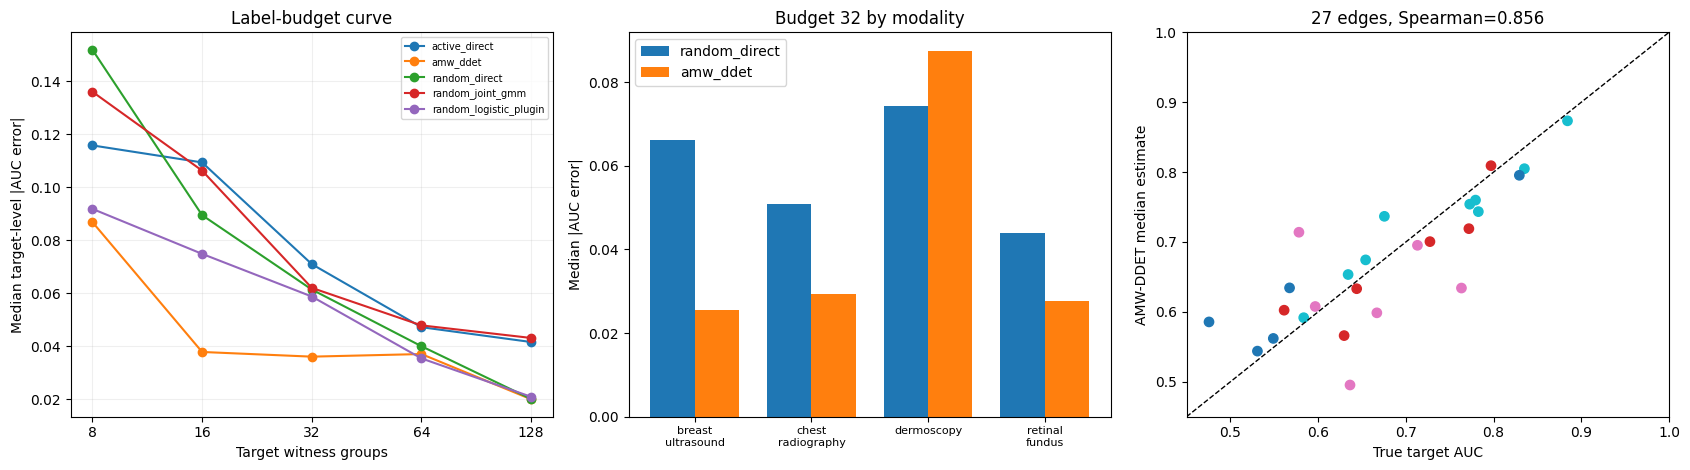

,method,median,mean,max
0,active_direct,0.070929,0.073743,0.139335
1,amw_ddet,0.036025,0.046853,0.107008
2,random_direct,0.061348,0.058625,0.092033
3,random_joint_gmm,0.061972,0.072775,0.131658
4,random_logistic_plugin,0.058710,0.051035,0.073913


method,modality,active_direct,amw_ddet,random_direct,random_joint_gmm,random_logistic_plugin
0,breast_ultrasound,0.047444,0.025513,0.066257,0.052619,0.058710
1,chest_radiography,0.081441,0.029281,0.050909,0.038746,0.048633
2,dermoscopy,0.080230,0.087560,0.074433,0.094822,0.064463
3,retinal_fundus,0.055490,0.027693,0.043987,0.065814,0.041366


,gate,observed,threshold,passed
0,G1_dataset_scope,13 targets / 27 edges / 4 modalities,13 / 27 / 4,True
1,G2_primary_mae,0.036025,<=0.04,True
2,G3_relative_improvement,0.412779,>=0.25,True
3,G4_target_signflip,0.036499,<=0.05,True
4,G5_edge_spearman,0.855922,>=0.80,True
5,G6_modality_noninferiority,3,>=3 of 4,True
6,G7_interval_coverage,0.98963,>=0.85,True
7,G8_wrong_decision_rate,0.003241,<=0.05,True
8,G9_decision_coverage,0.228519,>=0.10,True
9,G10_label_permutation,0.041658,<=0.05,True



===== STAGE T2-D COMPLETE =====
# Stage T2-D AMW-DDET result

- Decision: `AUTHORISE_AMW_DDET_METHOD_FREEZE_AND_BLIND_PREREGISTRATION_ONLY`
- Frozen gates: `11 / 11`
- Budget 32 AMW-DDET target-level median MAE: `0.036025`
- Random-direct target-level median MAE: `0.061348`
- Relative improvement: `0.412779`
- Target-cluster exact sign-flip p: `0.036499`
- Edge Spearman: `0.855922`
- LOTO interval coverage: `0.989630`
- Decision coverage / wrong-decision rate: `0.228519 / 0.003241`
- Label-permutation median |AUC-0.5|: `0.041658`

- Stage 12 authorised: `False`
- Locked blind assets touched: `False`

Development-only: passing authorises method freeze and blind preregistration, not a blind-data run.

Final record SHA256: 9feb5c20171c5c8f9aa3b63aa90b117d24dfe232c3775f40fedd2f3a6820a5fa


In [5]:
# @title T2-D-4. Target-cluster inference, conformal certificates, frozen gates, and final record
primary=results[(results.budget==32)&(results.method=='amw_ddet')].copy()
baseline=results[(results.budget==32)&(results.method=='random_direct')].copy()
assert primary[['source','target']].drop_duplicates().shape[0]==27
target_error=results[results.budget==32].groupby(['method','target','modality'],as_index=False).absolute_error.median()
method_summary=target_error.groupby('method').absolute_error.agg(['median','mean','max']).reset_index()
edge_summary=results[results.budget==32].groupby(['method','source','target','modality'],as_index=False).agg(estimate_auc=('estimate_auc','median'),true_auc=('true_auc','first'),absolute_error=('absolute_error','median'))
rank_rows=[]
for method,frame in edge_summary.groupby('method'):
    rank_rows.append({'method':method,'edges':len(frame),'spearman':spearmanr(frame.estimate_auc,frame.true_auc).statistic,'median_absolute_error':frame.absolute_error.median()})
rank_summary=pd.DataFrame(rank_rows)

proposed_target=target_error[target_error.method=='amw_ddet'].set_index('target').absolute_error
direct_target=target_error[target_error.method=='random_direct'].set_index('target').absolute_error
differences=(direct_target-proposed_target).dropna(); observed=differences.mean(); null=[]
for mask in range(1<<len(differences)):
    signs=np.asarray([1 if (mask>>index)&1 else -1 for index in range(len(differences))])
    null.append(float(np.mean(differences.to_numpy()*signs)))
signflip_p=float(np.mean(np.asarray(null)>=observed))
proposed_mae=float(proposed_target.median()); direct_mae=float(direct_target.median())
relative_improvement=float(1-proposed_mae/direct_mae)

modality_target=target_error.groupby(['method','modality'],as_index=False).absolute_error.median()
modality_wide=modality_target.pivot(index='modality',columns='method',values='absolute_error').reset_index()
modalities_noninferior=int((modality_wide.amw_ddet<=modality_wide.random_direct).sum())
edge_rho=float(rank_summary.set_index('method').loc['amw_ddet','spearman'])

certificate_rows=[]
for target in sorted(primary.target.unique()):
    calibration=primary[primary.target!=target].groupby('target').absolute_error.quantile(0.90).sort_values()
    n=len(calibration); order=min(n,int(np.ceil((n+1)*(1-ALPHA)))); radius=float(calibration.iloc[order-1])
    held=primary[primary.target==target].copy(); held['conformal_radius']=radius
    held['lower_auc']=np.clip(held.estimate_auc-radius,0,1); held['upper_auc']=np.clip(held.estimate_auc+radius,0,1)
    held['status']=np.where(held.lower_auc>=held.retention_threshold,'CERTIFIED_RETAINED',np.where(held.upper_auc<held.retention_threshold,'EXCLUDED','UNIDENTIFIABLE'))
    held['truth_retained']=held.true_auc>=held.retention_threshold
    held['interval_covers_truth']=(held.true_auc>=held.lower_auc)&(held.true_auc<=held.upper_auc)
    held['wrong_decision']=((held.status=='CERTIFIED_RETAINED')&(~held.truth_retained))|((held.status=='EXCLUDED')&(held.truth_retained))
    certificate_rows.append(held)
certificates=pd.concat(certificate_rows,ignore_index=True)
interval_coverage=float(certificates.interval_covers_truth.mean()); decided=certificates.status!='UNIDENTIFIABLE'
decision_coverage=float(decided.mean()); wrong_decision_rate=float(certificates.loc[decided,'wrong_decision'].mean()) if decided.any() else 1.0
negative_deviation=float(negative.absolute_deviation_from_0_5.median())

gates=pd.DataFrame([
    {'gate':'G1_dataset_scope','observed':f'{len(target_tables)} targets / {eligible_edges} edges / 4 modalities','threshold':'13 / 27 / 4','passed':len(target_tables)>=13 and eligible_edges>=27},
    {'gate':'G2_primary_mae','observed':proposed_mae,'threshold':'<=0.04','passed':proposed_mae<=THRESHOLDS['mae_max']},
    {'gate':'G3_relative_improvement','observed':relative_improvement,'threshold':'>=0.25','passed':relative_improvement>=THRESHOLDS['relative_improvement_min']},
    {'gate':'G4_target_signflip','observed':signflip_p,'threshold':'<=0.05','passed':signflip_p<=THRESHOLDS['signflip_p_max']},
    {'gate':'G5_edge_spearman','observed':edge_rho,'threshold':'>=0.80','passed':edge_rho>=THRESHOLDS['edge_spearman_min']},
    {'gate':'G6_modality_noninferiority','observed':modalities_noninferior,'threshold':'>=3 of 4','passed':modalities_noninferior>=THRESHOLDS['modalities_noninferior_min']},
    {'gate':'G7_interval_coverage','observed':interval_coverage,'threshold':'>=0.85','passed':interval_coverage>=THRESHOLDS['coverage_min']},
    {'gate':'G8_wrong_decision_rate','observed':wrong_decision_rate,'threshold':'<=0.05','passed':wrong_decision_rate<=THRESHOLDS['wrong_decision_rate_max']},
    {'gate':'G9_decision_coverage','observed':decision_coverage,'threshold':'>=0.10','passed':decision_coverage>=THRESHOLDS['decision_coverage_min']},
    {'gate':'G10_label_permutation','observed':negative_deviation,'threshold':'<=0.05','passed':negative_deviation<=THRESHOLDS['negative_control_median_deviation_max']},
    {'gate':'G11_blind_untouched','observed':True,'threshold':'True','passed':True},
])
gates['passed']=gates.passed.astype(bool); gate_count=int(gates.passed.sum())
decision='AUTHORISE_AMW_DDET_METHOD_FREEZE_AND_BLIND_PREREGISTRATION_ONLY' if gate_count==len(gates) else 'DO_NOT_AUTHORISE_BLIND_VALIDATION_REVISE_OR_TERMINATE'

curve=results.groupby(['method','budget','target'],as_index=False).absolute_error.median().groupby(['method','budget']).absolute_error.agg(['median',lambda x:x.quantile(.25),lambda x:x.quantile(.75)]).reset_index()
curve.columns=['method','budget','median_target_mae','q25_target_mae','q75_target_mae']
write_csv_once(P2/'StageT2-D_Method_Summary_Budget32_v0.1.csv',method_summary)
write_csv_once(P2/'StageT2-D_Edge_Rank_Summary_Budget32_v0.1.csv',rank_summary)
write_csv_once(P2/'StageT2-D_Learning_Curves_v0.1.csv',curve)
write_csv_once(P2/'StageT2-D_Modality_Summary_Budget32_v0.1.csv',modality_wide)
write_csv_once(P3/'StageT2-D_LOTO_Conformal_Certificates_v0.1.csv',certificates)
write_csv_once(P3/'StageT2-D_Frozen_Gates_v0.1.csv',gates)

fig,axes=plt.subplots(1,3,figsize=(17,4.8))
for method,frame in curve.groupby('method'):
    axes[0].plot(frame.budget,frame.median_target_mae,marker='o',label=method)
axes[0].set_xscale('log',base=2); axes[0].set_xticks(BUDGETS,BUDGETS); axes[0].set_xlabel('Target witness groups'); axes[0].set_ylabel('Median target-level |AUC error|'); axes[0].set_title('Label-budget curve'); axes[0].grid(alpha=.2); axes[0].legend(fontsize=7)
positions=np.arange(len(modality_wide)); width=.38
axes[1].bar(positions-width/2,modality_wide.random_direct,width,label='random_direct'); axes[1].bar(positions+width/2,modality_wide.amw_ddet,width,label='amw_ddet')
axes[1].set_xticks(positions,[value.replace('_','\n') for value in modality_wide.modality],fontsize=8); axes[1].set_ylabel('Median |AUC error|'); axes[1].set_title('Budget 32 by modality'); axes[1].legend()
edge_point=edge_summary[edge_summary.method=='amw_ddet']
axes[2].scatter(edge_point.true_auc,edge_point.estimate_auc,c=edge_point.modality.astype('category').cat.codes,cmap='tab10',s=45)
axes[2].plot([0.45,1],[0.45,1],'k--',lw=1); axes[2].set_xlim(.45,1); axes[2].set_ylim(.45,1); axes[2].set_xlabel('True target AUC'); axes[2].set_ylabel('AMW-DDET median estimate'); axes[2].set_title(f'27 edges, Spearman={edge_rho:.3f}')
fig.tight_layout(); figure_path=P4/'StageT2-D_AMW-DDET_Main_Figure_v0.1.png'
if not figure_path.exists(): fig.savefig(figure_path,dpi=180,bbox_inches='tight')
plt.show()

metrics={
    'primary_budget':32,'eligible_targets':len(target_tables),'eligible_edges':eligible_edges,'modalities':4,
    'amw_ddet_target_level_median_mae':proposed_mae,'random_direct_target_level_median_mae':direct_mae,
    'relative_improvement':relative_improvement,'target_cluster_exact_signflip_p':signflip_p,
    'edge_spearman':edge_rho,'modalities_noninferior':modalities_noninferior,
    'loto_interval_coverage':interval_coverage,'decision_coverage':decision_coverage,
    'wrong_decision_rate_among_decided':wrong_decision_rate,'negative_control_median_abs_deviation':negative_deviation,
}
final_payload={
    'stage':'StageT2-D','analysis':'development_only','protocol_seal_sha256':protocol['seal_sha256'],
    'metrics':metrics,'frozen_gates_passed':gate_count,'frozen_gates_total':len(gates),'decision':decision,
    'formal_replicates_expected':100,'replicates_executed':N_REPLICATES,'local_fast_mode':LOCAL_MODE,
    'stage12_authorised':False,'locked_blind_assets_touched':False,
    'result_sha256':{
        'replicates':sha_file(P1/'StageT2-D_All_Acquisition_Replicates_v0.1.csv'),
        'certificates':sha_file(P3/'StageT2-D_LOTO_Conformal_Certificates_v0.1.csv'),
        'gates':sha_file(P3/'StageT2-D_Frozen_Gates_v0.1.csv'),
    },
}
final=seal(P4/'StageT2-D_Complete_v0.1.json',final_payload,'final_record_sha256','completed_utc')
summary='\n'.join([
    '# Stage T2-D AMW-DDET result', '',
    f'- Decision: `{decision}`',f'- Frozen gates: `{gate_count} / {len(gates)}`',
    f'- Budget 32 AMW-DDET target-level median MAE: `{proposed_mae:.6f}`',
    f'- Random-direct target-level median MAE: `{direct_mae:.6f}`',
    f'- Relative improvement: `{relative_improvement:.6f}`',f'- Target-cluster exact sign-flip p: `{signflip_p:.6f}`',
    f'- Edge Spearman: `{edge_rho:.6f}`',f'- LOTO interval coverage: `{interval_coverage:.6f}`',
    f'- Decision coverage / wrong-decision rate: `{decision_coverage:.6f} / {wrong_decision_rate:.6f}`',
    f'- Label-permutation median |AUC-0.5|: `{negative_deviation:.6f}`','',
    '- Stage 12 authorised: `False`','- Locked blind assets touched: `False`','',
    'Development-only: passing authorises method freeze and blind preregistration, not a blind-data run.',
])+'\n'
write_text_once(P4/'StageT2-D_Result_Summary_v0.1.md',summary)
display(method_summary); display(modality_wide); display(gates)
print('\n===== STAGE T2-D COMPLETE =====')
print(summary)
print('Final record SHA256:',final['final_record_sha256'])


## 解释约束

- 通过 11/11 只说明 AMW-DDET 在已解封 development 边上达到冻结门槛；不能称为 blind validation。
- `random_joint_gmm` 是透明的半监督联合模型基线，不等价于 SSME 官方实现；正式投稿前必须补齐官方 SSME 与 Active Testing 的等预算比较。
- AUC 证书不认证校准、固定操作点、临床净获益或跨标签语义安全性。
- 若皮肤镜模态不劣性失败、区间覆盖不足或出现错误正向证书，应保留失败并停止 blind 授权。
